<a href="https://colab.research.google.com/github/lauria02/my-colab-projects/blob/main/skill_demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving job_postings_flat.csv to job_postings_flat.csv


In [ ]:
df = pd.read_csv('job_postings_flat.csv')

In [21]:
df['job_posted_date'] = pd.to_datetime(
    df['job_posted_date'],
    errors='coerce'
)

In [22]:
df['job_posted_date'].isna().sum()

np.int64(285845)

In [20]:
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [23]:
df.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Data Analyst,"Summer Internship -Data Analyst Intern, Risk M...","Marlborough, MA",via Boatingrevealed.com,"Full-time, Part-time, and Internship",False,"New York, United States",2024-01-01,False,True,United States,NaN,NaN,NaN,BJ's Wholesale Club,[excel],{'analyst_tools': ['excel']}
1,Data Analyst,"Staff Data Analyst Operations, Infrastructure ...","Fremont, CA",via ClimateTechList,Full-time,False,"California, United States",2024-01-01,True,False,United States,NaN,NaN,NaN,Tesla,"[tableau, flow]","{'analyst_tools': ['tableau'], 'other': ['flow']}"
2,Data Analyst,Junior Data Analyst - Entry Level,"Waco, TX",via ZipRecruiter,Full-time and Part-time,False,"Texas, United States",2024-01-01,True,False,United States,NaN,NaN,NaN,Next Recruiting,NaN,NaN
3,Data Analyst,"Data Analyst/Engineer, Supply Chain Optimizati...","Austin, TX",via ClimateTechList,Internship,False,"Texas, United States",2024-01-01,False,False,United States,NaN,NaN,NaN,Tesla,[spring],{'libraries': ['spring']}
4,Data Scientist,It analyst,"Tampa, FL",via Talent.com,Full-time,False,"Florida, United States",2024-01-01,True,False,United States,NaN,NaN,NaN,VirtualVocations,NaN,NaN


Filter Data for the United States

Filter the data for the market of the United States.

In [24]:
df_US = df[df['job_country'] == 'United States']

Explode Skills

In [25]:
df_skills = df_US.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
0,"Summer Internship -Data Analyst Intern, Risk M...",excel
1,"Staff Data Analyst Operations, Infrastructure ...",tableau
1,"Staff Data Analyst Operations, Infrastructure ...",flow
2,Junior Data Analyst - Entry Level,NaN
3,"Data Analyst/Engineer, Supply Chain Optimizati...",spring
...,...,...
478893,Machine Learning Operations Data Engineer IV -...,scikit-learn
478893,Machine Learning Operations Data Engineer IV -...,tidyverse
478893,Machine Learning Operations Data Engineer IV -...,docker
478893,Machine Learning Operations Data Engineer IV -...,kubernetes


Count Skills per Job Title

In [26]:
# Group by job_skills and job_title_short and count the number of occurrences
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

# Name the count column as count
df_skills_count = df_skills_count.reset_index(name='skill_count')

# Sort the values by skill_count in descending order
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1155,python,Data Scientist,24039
1454,sql,Data Engineer,22812
1154,python,Data Engineer,21520
1453,sql,Data Analyst,18929
1455,sql,Data Scientist,16994
...,...,...,...
279,cordova,Senior Data Engineer,1
962,notion,Software Engineer,1
840,mlr,Data Analyst,1
826,microsoft teams,Machine Learning Engineer,1


List of Top 3 Roles

In [27]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

Plot Skill Counts

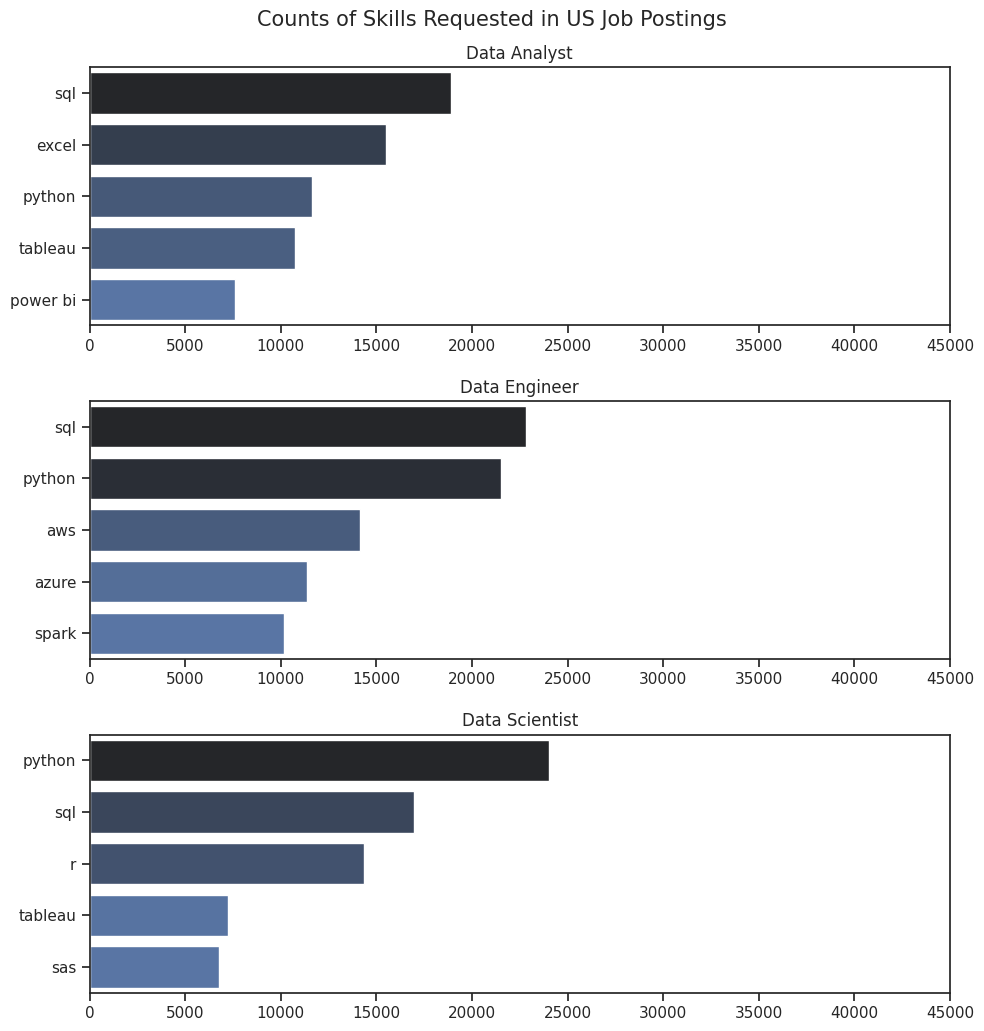

In [28]:
# 1. Added figsize to give the plots vertical breathing room
fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, len(job_titles) * 3.5))

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)

    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r', legend=False)

    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 45000)

fig.suptitle('Counts of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=1.5) # Increased padding slightly for better label spacing
plt.show()


Convert Counts to Percentages

In [29]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,39905
1,Data Scientist,34144
2,Data Engineer,33533
3,Senior Data Engineer,8160
4,Senior Data Scientist,7803
5,Business Analyst,7033
6,Senior Data Analyst,6099
7,Software Engineer,1702
8,Machine Learning Engineer,1603
9,Cloud Engineer,383


In [30]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,24039,34144,70.404756
1,sql,Data Engineer,22812,33533,68.028509
2,python,Data Engineer,21520,33533,64.175588
3,sql,Data Analyst,18929,39905,47.435159
4,sql,Data Scientist,16994,34144,49.771556
...,...,...,...,...,...
1792,cordova,Senior Data Engineer,1,8160,0.012255
1793,notion,Software Engineer,1,1702,0.058754
1794,mlr,Data Analyst,1,39905,0.002506
1795,microsoft teams,Machine Learning Engineer,1,1603,0.062383


Plot Percentage Count

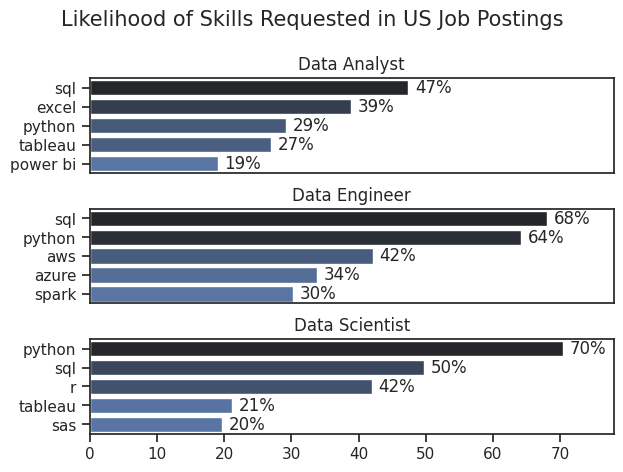

In [31]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()